# Density Overlap Integral Between Two Molecules

The **density overlap integral** measures how much the electron densities of two molecules co-occupy the same region of space:

$$\Omega_{AB} = \int \rho_A(\mathbf{r})\, \rho_B(\mathbf{r})\, d\mathbf{r}$$

Expanding each density in atomic orbital (AO) basis functions $\phi_\mu$:

$$\rho(\mathbf{r}) = \sum_{\mu\nu} P_{\mu\nu}\, \phi_\mu(\mathbf{r})\, \phi_\nu(\mathbf{r})$$

the integral becomes a contraction over density matrix elements and **4-center 1-electron overlap integrals**:

$$\Omega_{AB} = \sum_{\mu\nu \in A}\; \sum_{\lambda\sigma \in B} P^A_{\mu\nu}\, P^B_{\lambda\sigma} \int \phi^A_\mu(\mathbf{r})\, \phi^A_\nu(\mathbf{r})\, \phi^B_\lambda(\mathbf{r})\, \phi^B_\sigma(\mathbf{r})\, d\mathbf{r}$$

This notebook covers:
1. Building density matrices from **canonical MO (CMO)** coefficients
2. Building density matrices from **localized MO (LMO)** coefficients (Boys & Pipek–Mezey)
3. **Numerical grid integration** of $\Omega_{AB}$
4. **Approximate analytic formula** using the AO overlap matrix
5. **Distance dependence** of $\Omega_{AB}$
6. **LMO pair decomposition** — which orbital pairs drive the overlap

## 0. Imports

In [1]:
# Uncomment to install if needed
# !pip install pyscf numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, lo
from pyscf.dft import gen_grid, numint

print('PySCF and NumPy loaded.')

PySCF and NumPy loaded.


## 1. Define two molecules

Wat1 and Wat2 — two water molecules at their specified geometries, STO-3G basis.

In [2]:
molA = gto.M(
    atom='''
        O  -1.464000   0.099000   0.300000
        H  -1.956000   0.624000  -0.340000
        H  -1.797000  -0.799000   0.206000
    ''',
    basis='sto-3g',
    verbose=0
)

molB = gto.M(
    atom='''
        O   1.369000   0.146000  -0.395000
        H   1.894000   0.486000   0.335000
        H   0.451000   0.165000  -0.083000
    ''',
    basis='sto-3g',
    verbose=0
)

print(f'Wat1: {molA.nao_nr()} AOs,  {molA.nelectron} electrons')
print(f'Wat2: {molB.nao_nr()} AOs,  {molB.nelectron} electrons')

Wat1: 7 AOs,  10 electrons
Wat2: 7 AOs,  10 electrons


## 2. Run RHF

In [3]:
mfA = scf.RHF(molA); mfA.verbose = 0; mfA.run()
mfB = scf.RHF(molB); mfB.verbose = 0; mfB.run()

print(f'E(A) = {mfA.e_tot:.6f} Eh')
print(f'E(B) = {mfB.e_tot:.6f} Eh')

E(A) = -74.963285 Eh
E(B) = -74.963573 Eh


## 3. Density matrix from canonical MO (CMO) coefficients

The 1-particle reduced density matrix is:

$$\mathbf{P} = 2\,\mathbf{C}_{\text{occ}}\,\mathbf{C}_{\text{occ}}^T$$

where $\mathbf{C}_{\text{occ}}$ contains only the **occupied** MO columns (shape `nAO × n_occ`).
The factor of 2 accounts for double-occupation of each spatial orbital in closed-shell RHF.

`mf.make_rdm1()` does exactly this internally — we verify they agree.

In [4]:
def dm_from_cmo(mf):
    """Build density matrix from occupied canonical MO coefficients."""
    C     = mf.mo_coeff              # (nAO, nMO)
    occ   = mf.mo_occ                # occupation numbers: 2.0 or 0.0
    C_occ = C[:, occ > 0]            # (nAO, n_occ)  — keep occupied columns
    return 2 * C_occ @ C_occ.T       # (nAO, nAO)


dmA_cmo = dm_from_cmo(mfA)
dmB_cmo = dm_from_cmo(mfB)

# Verify against PySCF's built-in
print('Max |P_CMO - make_rdm1| for A:', np.max(np.abs(dmA_cmo - mfA.make_rdm1())))
print('Max |P_CMO - make_rdm1| for B:', np.max(np.abs(dmB_cmo - mfB.make_rdm1())))

# Sanity: Tr[PS] = N_electrons  (S = AO overlap)
SA = molA.intor('int1e_ovlp')
SB = molB.intor('int1e_ovlp')
print(f'Tr[P_A S_A] = {np.trace(dmA_cmo @ SA):.4f}  (should be {molA.nelectron})')
print(f'Tr[P_B S_B] = {np.trace(dmB_cmo @ SB):.4f}  (should be {molB.nelectron})')

Max |P_CMO - make_rdm1| for A: 0.0
Max |P_CMO - make_rdm1| for B: 0.0
Tr[P_A S_A] = 10.0000  (should be 10)
Tr[P_B S_B] = 10.0000  (should be 10)


## 4. Density matrix from localized MO (LMO) coefficients

LMOs are a **unitary rotation** of the occupied CMOs:

$$\mathbf{C}_{\text{LMO}} = \mathbf{C}_{\text{occ}}\,\mathbf{U}, \qquad \mathbf{U}\mathbf{U}^T = \mathbf{I}$$

Because $\mathbf{U}$ is unitary, the density matrix is **invariant**:

$$\mathbf{P} = 2\,\mathbf{C}_{\text{LMO}}\mathbf{C}_{\text{LMO}}^T
             = 2\,\mathbf{C}_{\text{occ}}\underbrace{\mathbf{U}\mathbf{U}^T}_{=\mathbf{I}}\mathbf{C}_{\text{occ}}^T
             = 2\,\mathbf{C}_{\text{occ}}\mathbf{C}_{\text{occ}}^T$$

The density is a physical observable — it cannot depend on the orbital representation.

We demonstrate two common localization schemes:
- **Boys** (Foster–Boys): minimizes spread $\langle r^2\rangle - \langle r\rangle^2$ of each orbital
- **Pipek–Mezey (PM)**: maximizes atomic charge localization (preserves σ/π separation)

In [5]:
def dm_from_lmo(mf, mol, method='boys'):
    """
    Localize occupied MOs and return (C_lmo, P).
    method: 'boys' or 'pm'
    """
    C_occ = mf.mo_coeff[:, mf.mo_occ > 0]   # (nAO, n_occ)

    if method == 'boys':
        loc = lo.Boys(mol, C_occ)
    elif method == 'pm':
        loc = lo.PM(mol, C_occ)
    else:
        raise ValueError(f'Unknown method: {method}')

    C_lmo = loc.kernel()                     # (nAO, n_occ)
    P     = 2 * C_lmo @ C_lmo.T             # (nAO, nAO)
    return C_lmo, P


C_boysA, dmA_boys = dm_from_lmo(mfA, molA, 'boys')
C_boysB, dmB_boys = dm_from_lmo(mfB, molB, 'boys')

C_pmA, dmA_pm = dm_from_lmo(mfA, molA, 'pm')
C_pmB, dmB_pm = dm_from_lmo(mfB, molB, 'pm')

print('Molecule A — max |P_CMO - P_Boys|:', np.max(np.abs(dmA_cmo - dmA_boys)))
print('Molecule A — max |P_CMO - P_PM|:  ', np.max(np.abs(dmA_cmo - dmA_pm)))
print('Molecule B — max |P_CMO - P_Boys|:', np.max(np.abs(dmB_cmo - dmB_boys)))
print('Molecule B — max |P_CMO - P_PM|:  ', np.max(np.abs(dmB_cmo - dmB_pm)))
print('\n→ All density matrices are numerically identical (differences are floating-point noise).')

Molecule A — max |P_CMO - P_Boys|: 8.881784197001252e-16
Molecule A — max |P_CMO - P_PM|:   1.27675647831893e-15
Molecule B — max |P_CMO - P_Boys|: 6.661338147750939e-16
Molecule B — max |P_CMO - P_PM|:   2.220446049250313e-15

→ All density matrices are numerically identical (differences are floating-point noise).


### LMO orbital centroids

Unlike delocalized CMOs, each LMO has a well-defined centre — useful for
assigning orbitals to bonds, lone pairs, or functional groups.

In [6]:
def lmo_centroids(mol, C_lmo):
    """Return (n_occ, 3) array of LMO expectation values <r>."""
    r_ints = mol.intor('int1e_r')           # (3, nAO, nAO) dipole integrals
    return np.array([
        [np.einsum('ij,ji->', r_ints[k], np.outer(C_lmo[:, i], C_lmo[:, i]))
         for k in range(3)]
        for i in range(C_lmo.shape[1])
    ])                                      # (n_occ, 3)


cents_A = lmo_centroids(molA, C_boysA)
print('Boys LMO centroids for molecule A (Bohr):')
print(f'  {"LMO":>4}  {"x":>8}  {"y":>8}  {"z":>8}')
for i, c in enumerate(cents_A):
    print(f'  {i:>4}  {c[0]:>8.3f}  {c[1]:>8.3f}  {c[2]:>8.3f}')

Boys LMO centroids for molecule A (Bohr):
   LMO         x         y         z
     0    -2.767     0.187     0.566
     1    -3.154    -0.828     0.450
     2    -3.332     0.772    -0.164
     3    -2.212     0.187     0.406
     4    -2.909     0.374     1.095


## 5. Numerical grid integration of $\Omega_{AB}$

$$\Omega_{AB} \approx \sum_g w_g\, \rho_A(\mathbf{r}_g)\, \rho_B(\mathbf{r}_g)$$

Because the density matrix is the same regardless of orbital basis (CMO or LMO),
the total $\Omega_{AB}$ is identical in all cases — verified below.

In [7]:
def build_union_grid(mol1, mol2, level=3):
    g1 = gen_grid.Grids(mol1); g1.level = level; g1.build()
    g2 = gen_grid.Grids(mol2); g2.level = level; g2.build()
    return np.vstack([g1.coords, g2.coords]), np.concatenate([g1.weights, g2.weights])


def eval_density(mol, dm, coords):
    ao  = numint.eval_ao(mol, coords)              # (npts, nAO)
    return np.einsum('pi,ij,pj->p', ao, dm, ao)   # (npts,)


def density_overlap(mol1, dm1, mol2, dm2, level=3):
    coords, weights = build_union_grid(mol1, mol2, level)
    rho1 = eval_density(mol1, dm1, coords)
    rho2 = eval_density(mol2, dm2, coords)
    return float(np.dot(weights, rho1 * rho2))


coords, weights = build_union_grid(molA, molB, level=3)
rhoA = eval_density(molA, dmA_cmo, coords)
rhoB = eval_density(molB, dmB_cmo, coords)

omega_cmo   = np.dot(weights, rhoA * rhoB)
omega_boys  = density_overlap(molA, dmA_boys, molB, dmB_boys)
omega_pm    = density_overlap(molA, dmA_pm,   molB, dmB_pm)

print(f'Ω_AB  (CMO density matrix)  = {omega_cmo:.8f}')
print(f'Ω_AB  (Boys density matrix) = {omega_boys:.8f}')
print(f'Ω_AB  (PM density matrix)   = {omega_pm:.8f}')
print('\n→ All three are identical — the total overlap is basis-representation-invariant.')

Ω_AB  (CMO density matrix)  = 0.00207374
Ω_AB  (Boys density matrix) = 0.00207374
Ω_AB  (PM density matrix)   = 0.00207374

→ All three are identical — the total overlap is basis-representation-invariant.


### 5a. Visualize the density overlap integrand

Plot $\rho_A$, $\rho_B$, and their product $\rho_A \cdot \rho_B$ (the integrand of $\Omega_{AB}$)
on a 2D slice through the XY plane at $z = 0$.  Atom positions are projected onto this plane.

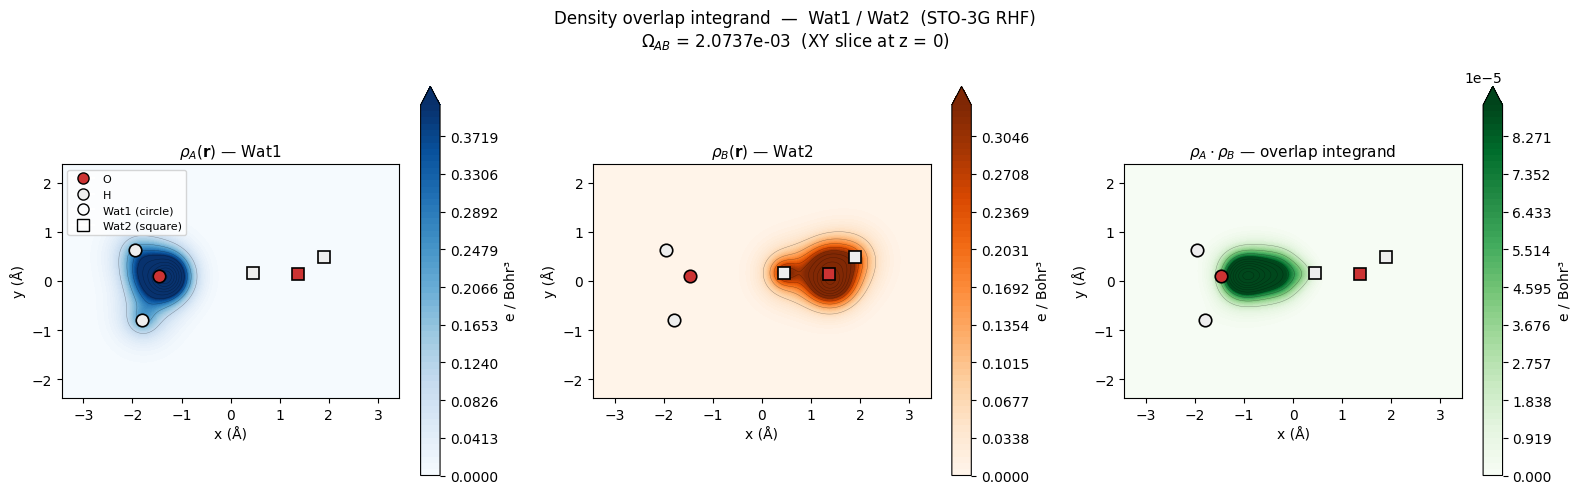

Saved: density_overlap_integrand.png


In [8]:
BOHR_TO_ANG = 0.529177210903   # 1 Bohr in Angstrom

# ── 2D grid in the XY plane (z = 0), coordinates in Bohr ─────────────────────
nx, ny = 300, 300
x_bohr = np.linspace(-6.5,  6.5, nx)
y_bohr = np.linspace(-4.5,  4.5, ny)
xx, yy = np.meshgrid(x_bohr, y_bohr)
grid_2d = np.column_stack([xx.ravel(), yy.ravel(), np.zeros(nx * ny)])

# ── Evaluate densities on the 2D grid ────────────────────────────────────────
rhoA_2d = eval_density(molA, dmA_cmo, grid_2d).reshape(ny, nx)
rhoB_2d = eval_density(molB, dmB_cmo, grid_2d).reshape(ny, nx)
prod_2d  = rhoA_2d * rhoB_2d

# Axis in Angstrom for readability
x_ang = x_bohr * BOHR_TO_ANG
y_ang = y_bohr * BOHR_TO_ANG

# ── Atom positions projected onto XY plane ────────────────────────────────────
def atom_xy_ang(mol):
    """Return (natom, 2) atom x,y positions in Angstrom."""
    coords = mol.atom_coords()          # (natom, 3) in Bohr
    return coords[:, :2] * BOHR_TO_ANG

def atom_colors(mol):
    return ['#cc3333' if mol.atom_symbol(i) == 'O' else '#eeeeee'
            for i in range(mol.natm)]

xyA = atom_xy_ang(molA);  colA = atom_colors(molA)
xyB = atom_xy_ang(molB);  colB = atom_colors(molB)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panels = [
    (rhoA_2d, r'$\rho_A(\mathbf{r})$ — Wat1',               'Blues'),
    (rhoB_2d, r'$\rho_B(\mathbf{r})$ — Wat2',               'Oranges'),
    (prod_2d, r'$\rho_A \cdot \rho_B$ — overlap integrand', 'Greens'),
]

for ax, (dens, title, cmap) in zip(axes, panels):
    vmax = np.percentile(dens[dens > 0], 98)   # clip nuclear spikes
    levels = np.linspace(0, vmax, 60)
    cf = ax.contourf(x_ang, y_ang, np.clip(dens, 0, vmax),
                     levels=levels, cmap=cmap, extend='max')
    ax.contour(x_ang, y_ang, dens, levels=10, colors='k', linewidths=0.3, alpha=0.4)
    plt.colorbar(cf, ax=ax, label='e / Bohr³')

    # Wat1 atoms (circles)
    for (x_, y_), c in zip(xyA, colA):
        ax.plot(x_, y_, 'o', color=c, ms=9, mec='black', mew=1.2, zorder=5)
    # Wat2 atoms (squares)
    for (x_, y_), c in zip(xyB, colB):
        ax.plot(x_, y_, 's', color=c, ms=9, mec='black', mew=1.2, zorder=5)

    ax.set_xlabel('x (Å)')
    ax.set_ylabel('y (Å)')
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#cc3333', ms=8, mec='k', label='O'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#eeeeee', ms=8, mec='k', label='H'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',    ms=8, mec='k', label='Wat1 (circle)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='none',    ms=8, mec='k', label='Wat2 (square)'),
]
axes[0].legend(handles=legend_elements, fontsize=8, loc='upper left')

plt.suptitle(
    f'Density overlap integrand  —  Wat1 / Wat2  (STO-3G RHF)\n'
    f'$\\Omega_{{AB}}$ = {omega_cmo:.4e}  (XY slice at z = 0)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('density_overlap_integrand.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: density_overlap_integrand.png')

### 5b. 1D density overlap plot along the O–O axis

Evaluate $\rho_A$ and $\rho_B$ along the line connecting the two oxygen atoms.
The purple filled region $= \min(\rho_A, \rho_B)$ visualises where the two densities co-occupy space.

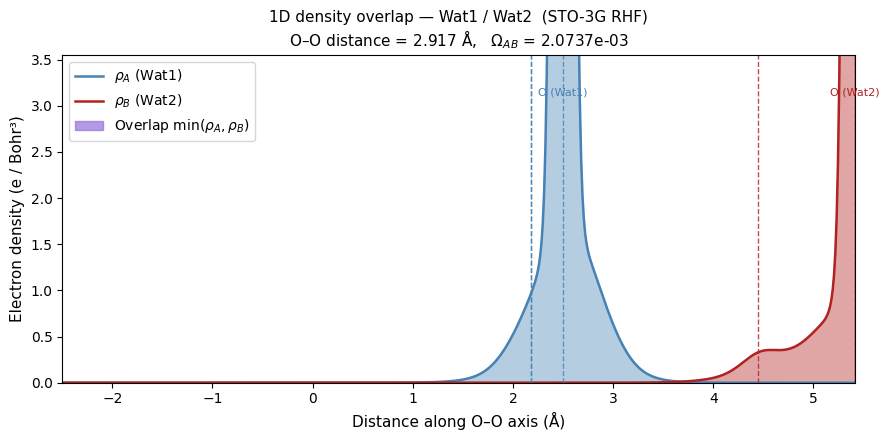

Saved: density_overlap_1d.png


In [9]:
BOHR_TO_ANG = 0.529177210903

# ── O–O axis ─────────────────────────────────────────────────────────────────
o_A = molA.atom_coords()[0] * BOHR_TO_ANG   # O of Wat1 in Å
o_B = molB.atom_coords()[0] * BOHR_TO_ANG   # O of Wat2 in Å

oo_vec  = o_B - o_A
oo_dist = np.linalg.norm(oo_vec)
oo_hat  = oo_vec / oo_dist                  # unit vector A→B

# 1D grid: start 2.5 Å before Wat1-O, end 2.5 Å after Wat2-O
pad = 2.5
t   = np.linspace(-pad, oo_dist + pad, 600)   # Å along the axis
origin_ang = o_A - pad * oo_hat

pts_ang  = origin_ang + t[:, None] * oo_hat   # (600, 3) in Å
pts_bohr = pts_ang / BOHR_TO_ANG              # in Bohr  (eval_ao needs Bohr)

# ── Evaluate densities along the line ────────────────────────────────────────
rhoA_1d = eval_density(molA, dmA_cmo, pts_bohr)
rhoB_1d = eval_density(molB, dmB_cmo, pts_bohr)

# ── Project all atom positions onto the O–O axis ─────────────────────────────
def project_atoms(mol, origin_ang, oo_hat):
    """Return 1D coordinates of each atom projected along oo_hat (Å)."""
    return np.dot(mol.atom_coords() * BOHR_TO_ANG - origin_ang, oo_hat)

proj_A = project_atoms(molA, origin_ang, oo_hat)   # x positions of Wat1 atoms
proj_B = project_atoms(molB, origin_ang, oo_hat)   # x positions of Wat2 atoms

sym_A = [molA.atom_symbol(i) for i in range(molA.natm)]
sym_B = [molB.atom_symbol(i) for i in range(molB.natm)]

# ── Clip y for readability (nuclear cusps are very tall) ─────────────────────
ymax = np.percentile(np.concatenate([rhoA_1d, rhoB_1d]), 97)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

# Filled density curves
ax.fill_between(t, rhoA_1d, alpha=0.40, color='steelblue')
ax.plot(t, rhoA_1d, color='steelblue', lw=1.8, label=r'$\rho_A$ (Wat1)')

ax.fill_between(t, rhoB_1d, alpha=0.40, color='firebrick')
ax.plot(t, rhoB_1d, color='firebrick', lw=1.8, label=r'$\rho_B$ (Wat2)')

# Overlap region = min(rhoA, rhoB)
ax.fill_between(t, np.minimum(rhoA_1d, rhoB_1d),
                alpha=0.70, color='mediumpurple',
                label=r'Overlap $\min(\rho_A,\rho_B)$')

# Dashed vertical lines at projected nuclear positions
for pos, sym in zip(proj_A, sym_A):
    ls = '--'
    ax.axvline(pos, color='steelblue', lw=1.0, ls=ls, alpha=0.8)

for pos, sym in zip(proj_B, sym_B):
    ax.axvline(pos, color='firebrick',  lw=1.0, ls='--', alpha=0.8)

# Annotations for O atoms
o_pos_A = proj_A[sym_A.index('O')]
o_pos_B = proj_B[sym_B.index('O')]
ax.annotate('O (Wat1)', xy=(o_pos_A, ymax * 0.92),
            ha='center', color='steelblue', fontsize=8)
ax.annotate('O (Wat2)', xy=(o_pos_B, ymax * 0.92),
            ha='center', color='firebrick', fontsize=8)

ax.set_xlabel('Distance along O–O axis (Å)', fontsize=11)
ax.set_ylabel('Electron density (e / Bohr³)', fontsize=11)
ax.set_title(
    f'1D density overlap — Wat1 / Wat2  (STO-3G RHF)\n'
    f'O–O distance = {oo_dist:.3f} Å,   $\\Omega_{{AB}}$ = {omega_cmo:.4e}',
    fontsize=11
)
ax.legend(fontsize=10)
ax.set_xlim(t[0], t[-1])
ax.set_ylim(0, ymax * 1.05)

plt.tight_layout()
plt.savefig('density_overlap_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: density_overlap_1d.png')

## 6. Approximate analytic formula

Using the cross-block AO overlap matrix $S^{AB}_{\mu\lambda} = \langle\phi^A_\mu|\phi^B_\lambda\rangle$:

$$\Omega_{AB} \approx \operatorname{Tr}\!\left[P_A\, S^{AB}\, P_B\, (S^{AB})^T\right]$$

In [10]:
def build_cross_overlap(mol1, mol2):
    nA = mol1.nao_nr()
    molAB = gto.M(
        atom=mol1._atom + mol2._atom,
        basis=mol1.basis,
        verbose=0
    )
    S_full = molAB.intor('int1e_ovlp')
    return S_full[:nA, nA:]


S_AB = build_cross_overlap(molA, molB)
print(f'Cross-overlap S_AB shape: {S_AB.shape}')
print(f'Max |S_AB|: {np.max(np.abs(S_AB)):.2e}  (small → molecules well-separated)')

omega_analytic = np.einsum('ij,jk,kl,li->', dmA_cmo, S_AB, dmB_cmo, S_AB.T)
print(f'\nΩ_AB (analytic approx) = {omega_analytic:.8f}')
print(f'Ω_AB (numerical)       = {omega_cmo:.8f}')
print(f'Difference:              {abs(omega_cmo - omega_analytic):.2e}')

Cross-overlap S_AB shape: (7, 7)
Max |S_AB|: 1.57e-03  (small → molecules well-separated)

Ω_AB (analytic approx) = 0.00000429
Ω_AB (numerical)       = 0.00207374
Difference:              2.07e-03


## 7. Distance dependence

d = 2.0 Å  →  Ω = 1.2013e-06


d = 2.5 Å  →  Ω = 4.6531e-08


d = 3.0 Å  →  Ω = 1.4863e-09


d = 3.5 Å  →  Ω = 3.7811e-11


d = 4.0 Å  →  Ω = 8.1690e-13


...

d = 5.5 Å  →  Ω = 3.7627e-18


d = 6.0 Å  →  Ω = 3.9209e-20


d = 6.5 Å  →  Ω = 3.0277e-22
d = 7.0 Å  →  Ω = 1.7276e-24


d = 7.5 Å  →  Ω = 7.3088e-27


d = 8.0 Å  →  Ω = 2.2869e-29


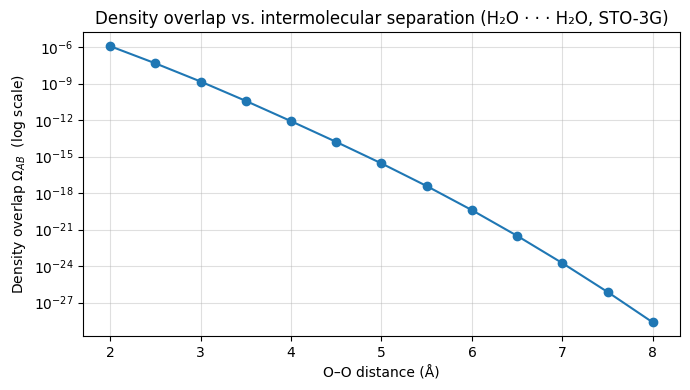

In [11]:
distances_angstrom = np.linspace(2.0, 8.0, 13)
omegas = []

for d in distances_angstrom:
    mol_b = gto.M(
        atom=f'O {d:.3f} 0 0; H {d:.3f} 0.757 0.586; H {d:.3f} -0.757 0.586',
        basis='sto-3g', verbose=0
    )
    mf_b = scf.RHF(mol_b); mf_b.verbose = 0; mf_b.run()
    omegas.append(density_overlap(molA, dmA_cmo, mol_b, mf_b.make_rdm1()))
    print(f'd = {d:.1f} Å  →  Ω = {omegas[-1]:.4e}')

plt.figure(figsize=(7, 4))
plt.semilogy(distances_angstrom, omegas, 'o-')
plt.xlabel('O–O distance (Å)')
plt.ylabel(r'Density overlap $\Omega_{AB}$  (log scale)')
plt.title('Density overlap vs. intermolecular separation (H₂O · · · H₂O, STO-3G)')
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('density_overlap_vs_distance.png', dpi=150)
plt.show()

## 8. LMO pair decomposition of $\Omega_{AB}$

Even though the *total* $\Omega_{AB}$ is the same for CMOs and LMOs, LMOs give a physically
meaningful **per-orbital-pair decomposition** because each LMO is spatially local.

Using the LMO densities:

$$\rho_A(\mathbf{r}) = 2\sum_i |\varphi_i^A(\mathbf{r})|^2, \qquad
  \rho_B(\mathbf{r}) = 2\sum_j |\varphi_j^B(\mathbf{r})|^2$$

the overlap decomposes exactly into pair contributions:

$$\Omega_{AB} = \sum_{i \in A}\sum_{j \in B} \omega_{ij}, \qquad
  \omega_{ij} = 4\int |\varphi_i^A(\mathbf{r})|^2 |\varphi_j^B(\mathbf{r})|^2\, d\mathbf{r}$$

Each $\omega_{ij}$ is a **non-negative** number representing how much LMO $i$ on molecule A
overlaps with LMO $j$ on molecule B. Localised orbitals (lone pairs, bonds) make this
decomposition interpretable.

In [12]:
def lmo_pair_overlap_matrix(mol1, C_lmo1, mol2, C_lmo2, level=3):
    """
    Returns omega[i, j] = 4 * int |phi_i^A|^2 |phi_j^B|^2 dr
    for all pairs of occupied LMOs from mol1 and mol2.
    """
    coords, weights = build_union_grid(mol1, mol2, level)

    ao1 = numint.eval_ao(mol1, coords)   # (npts, nAO1)
    ao2 = numint.eval_ao(mol2, coords)   # (npts, nAO2)

    n_occ1 = C_lmo1.shape[1]
    n_occ2 = C_lmo2.shape[1]

    # Evaluate each LMO on the grid: phi_i(r) = sum_mu C_mu,i * chi_mu(r)
    lmo1_grid = ao1 @ C_lmo1   # (npts, n_occ1)  phi_i^A(r)
    lmo2_grid = ao2 @ C_lmo2   # (npts, n_occ2)  phi_j^B(r)

    # Orbital densities: rho_i(r) = 2 |phi_i|^2
    orb_rho1 = 2 * lmo1_grid**2   # (npts, n_occ1)
    orb_rho2 = 2 * lmo2_grid**2   # (npts, n_occ2)

    # omega[i,j] = int rho_i^A(r) rho_j^B(r) dr
    #            = sum_g w_g * rho_i^A(r_g) * rho_j^B(r_g)
    #            = (orb_rho1 * w[:, None]).T @ orb_rho2
    omega_ij = (orb_rho1 * weights[:, None]).T @ orb_rho2   # (n_occ1, n_occ2)
    return omega_ij


omega_ij = lmo_pair_overlap_matrix(molA, C_boysA, molB, C_boysB)

print(f'Pair overlap matrix shape: {omega_ij.shape}  ({omega_ij.shape[0]} LMOs on A × {omega_ij.shape[1]} LMOs on B)')
print(f'Sum of all pairs Σ ω_ij  = {omega_ij.sum():.8f}')
print(f'Total Ω_AB (numerical)   = {omega_cmo:.8f}')
print(f'Difference               = {abs(omega_ij.sum() - omega_cmo):.2e}')

Pair overlap matrix shape: (5, 5)  (5 LMOs on A × 5 LMOs on B)
Sum of all pairs Σ ω_ij  = 0.00207374
Total Ω_AB (numerical)   = 0.00207374
Difference               = 1.30e-18


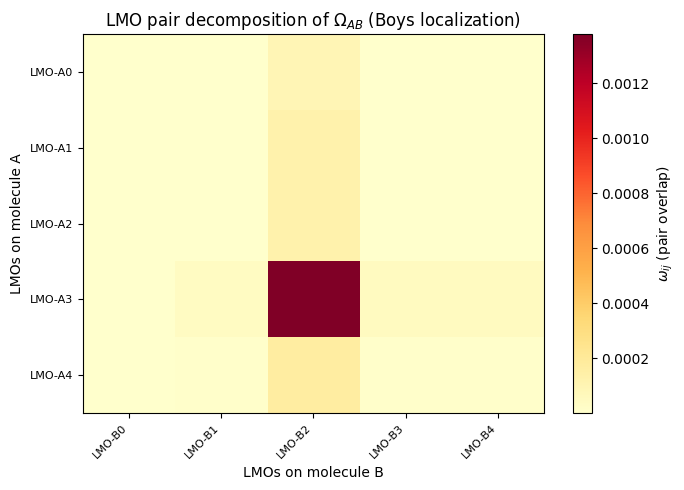


Top 5 orbital pair contributions:
    LMO on A    LMO on B          ω_ij  % of total
      LMO-A3      LMO-B2    1.3787e-03       66.5%
      LMO-A4      LMO-B2    1.6911e-04        8.2%
      LMO-A2      LMO-B2    1.2777e-04        6.2%
      LMO-A1      LMO-B2    1.2716e-04        6.1%
      LMO-A0      LMO-B2    8.8182e-05        4.3%


In [13]:
# Assign simple labels: use LMO index + centroid distance from molecule A origin
lmo_labels_A = [f'LMO-A{i}' for i in range(omega_ij.shape[0])]
lmo_labels_B = [f'LMO-B{j}' for j in range(omega_ij.shape[1])]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(omega_ij, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label=r'$\omega_{ij}$ (pair overlap)')
ax.set_xticks(range(len(lmo_labels_B)))
ax.set_yticks(range(len(lmo_labels_A)))
ax.set_xticklabels(lmo_labels_B, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(lmo_labels_A, fontsize=8)
ax.set_xlabel('LMOs on molecule B')
ax.set_ylabel('LMOs on molecule A')
ax.set_title('LMO pair decomposition of $\\Omega_{AB}$ (Boys localization)')
plt.tight_layout()
plt.savefig('lmo_pair_overlap_heatmap.png', dpi=150)
plt.show()

# Print top contributing pairs
flat_idx = np.argsort(omega_ij.ravel())[::-1]
print('\nTop 5 orbital pair contributions:')
print(f'  {"LMO on A":>10}  {"LMO on B":>10}  {"ω_ij":>12}  {"% of total":>10}')
total = omega_ij.sum()
for k in flat_idx[:5]:
    i, j = divmod(k, omega_ij.shape[1])
    print(f'  {lmo_labels_A[i]:>10}  {lmo_labels_B[j]:>10}  {omega_ij[i,j]:>12.4e}  {100*omega_ij[i,j]/total:>9.1f}%')

### CMO pair decomposition (for comparison)

The same decomposition with canonical MOs gives the same total but each individual
$\omega_{ij}$ is less interpretable because CMOs are delocalized.

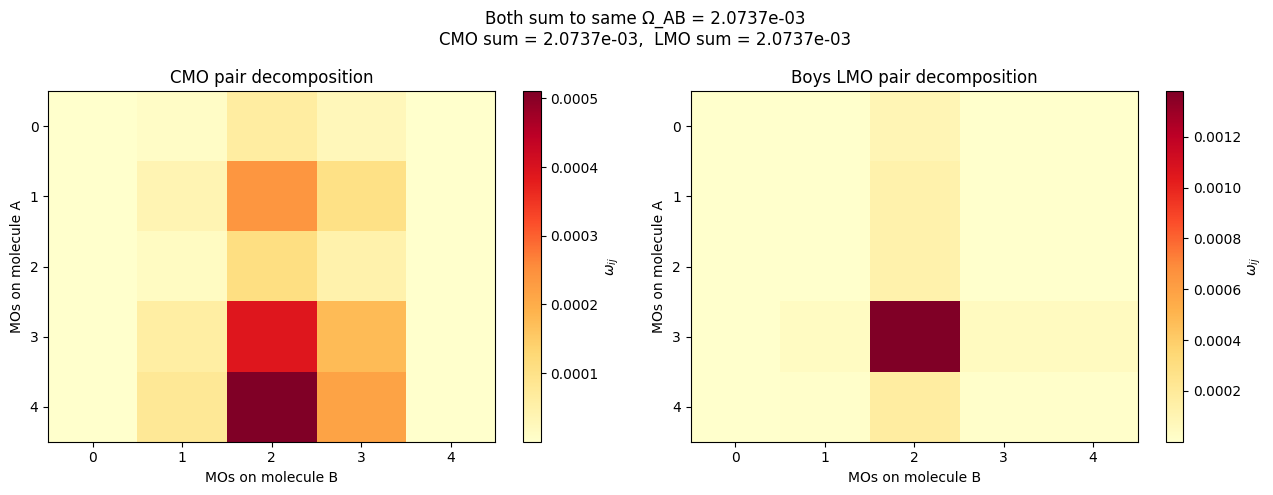

In [14]:
C_occA = mfA.mo_coeff[:, mfA.mo_occ > 0]
C_occB = mfB.mo_coeff[:, mfB.mo_occ > 0]

omega_ij_cmo = lmo_pair_overlap_matrix(molA, C_occA, molB, C_occB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(
    axes,
    [omega_ij_cmo, omega_ij],
    ['CMO pair decomposition', 'Boys LMO pair decomposition']
):
    im = ax.imshow(mat, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label=r'$\omega_{ij}$')
    ax.set_xlabel('MOs on molecule B')
    ax.set_ylabel('MOs on molecule A')
    ax.set_title(title)

plt.suptitle(
    f'Both sum to same Ω_AB = {omega_cmo:.4e}\n'
    f'CMO sum = {omega_ij_cmo.sum():.4e},  LMO sum = {omega_ij.sum():.4e}'
)
plt.tight_layout()
plt.savefig('cmo_vs_lmo_pair_decomposition.png', dpi=150)
plt.show()

### 8a. Spatial visualization of LMO contributions

Two figures:
1. **All LMO orbital densities** $\rho_i = 2|\varphi_i|^2$ on the XY plane — one panel per orbital, Wat1 on top row, Wat2 on bottom.
2. **Top pair integrands** $\rho_i^A \cdot \rho_j^B$ for the six largest $\omega_{ij}$ contributions.

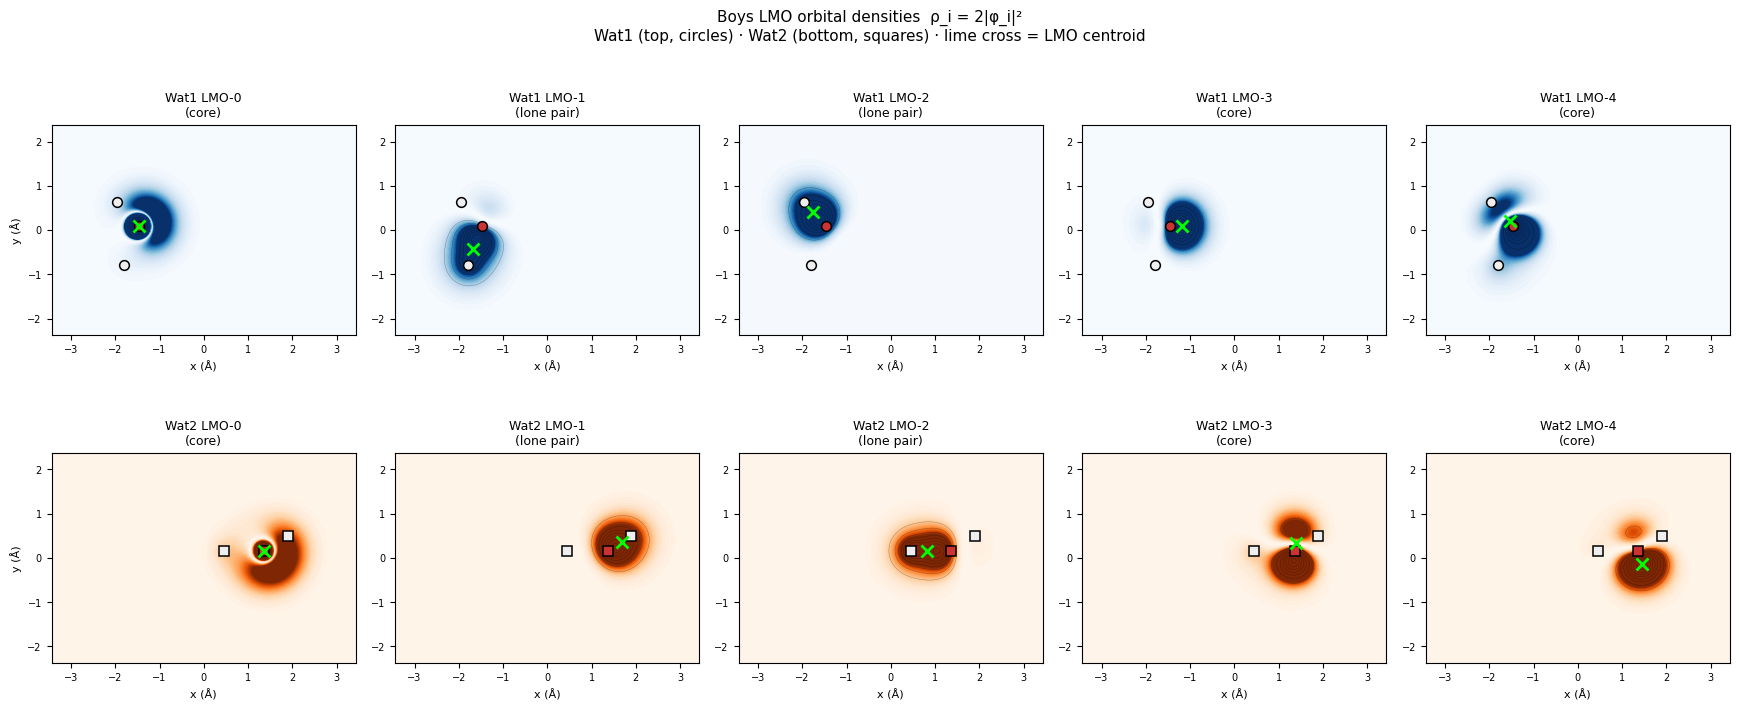

Saved: lmo_orbital_densities.png


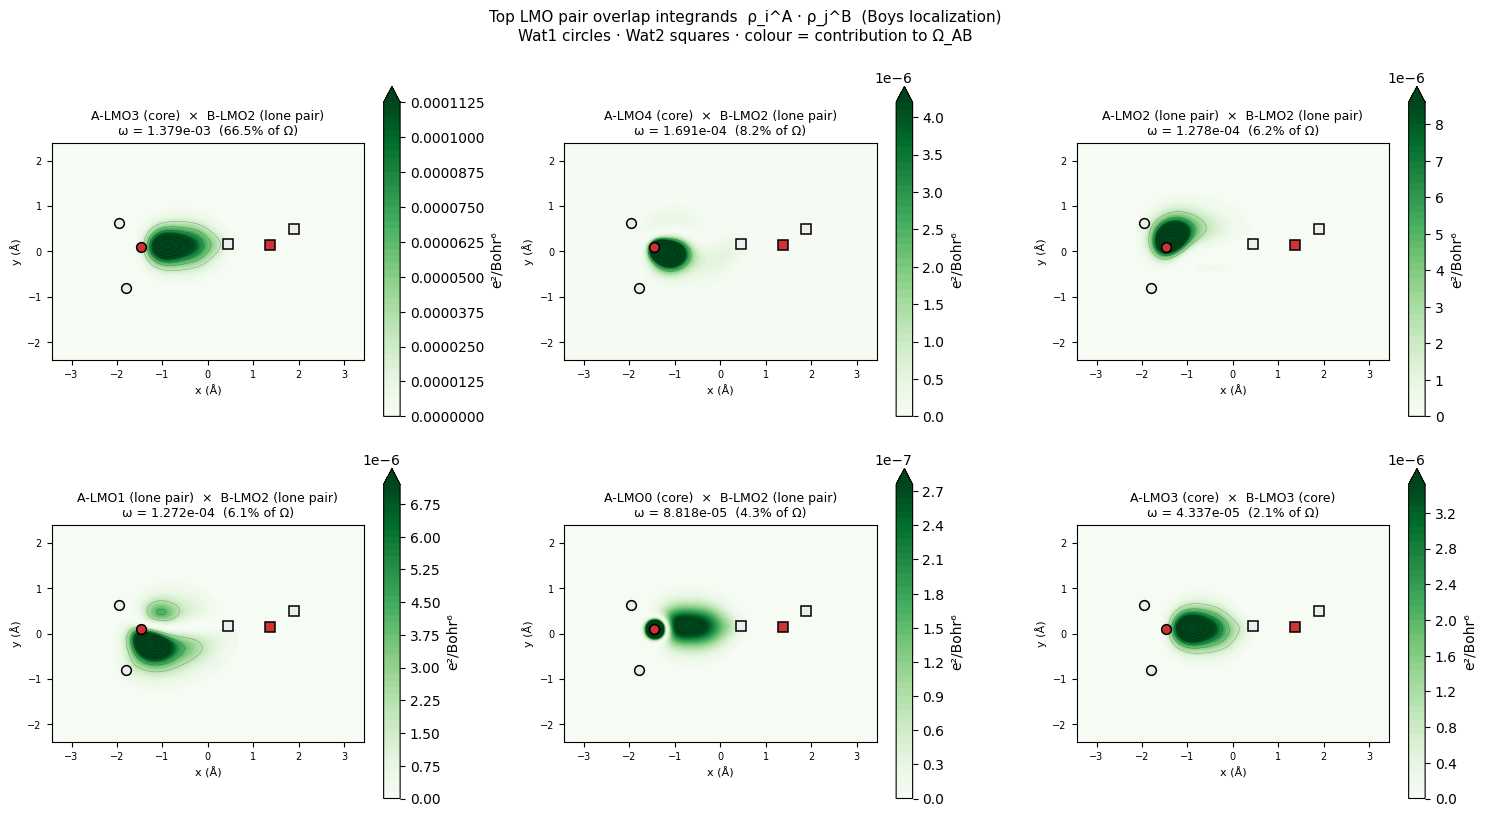

Saved: lmo_pair_integrands.png


In [15]:
BOHR_TO_ANG = 0.529177210903

# ── 2D grid in the XY plane (Bohr) ───────────────────────────────────────────
nx, ny = 250, 250
x_bohr = np.linspace(-6.5, 6.5, nx)
y_bohr = np.linspace(-4.5, 4.5, ny)
xx2, yy2 = np.meshgrid(x_bohr, y_bohr)
grid_lmo = np.column_stack([xx2.ravel(), yy2.ravel(), np.zeros(nx * ny)])
x_ang2 = x_bohr * BOHR_TO_ANG
y_ang2 = y_bohr * BOHR_TO_ANG

# ── Evaluate all LMO values and orbital densities on the grid ────────────────
ao1_g = numint.eval_ao(molA, grid_lmo)     # (npts, nAO_A)
ao2_g = numint.eval_ao(molB, grid_lmo)     # (npts, nAO_B)

lmo1_g = ao1_g @ C_boysA                  # (npts, n_occ_A)  phi_i^A(r)
lmo2_g = ao2_g @ C_boysB                  # (npts, n_occ_B)  phi_j^B(r)

orb_rho1_g = 2 * lmo1_g**2                # (npts, n_occ_A)  rho_i^A(r)
orb_rho2_g = 2 * lmo2_g**2                # (npts, n_occ_B)  rho_j^B(r)

n_occ_A = C_boysA.shape[1]
n_occ_B = C_boysB.shape[1]

# ── Atom positions and LMO centroids ─────────────────────────────────────────
def atom_xy_ang(mol):
    return mol.atom_coords()[:, :2] * BOHR_TO_ANG

def atom_markers(mol):
    return ['#cc3333' if mol.atom_symbol(i) == 'O' else '#eeeeee'
            for i in range(mol.natm)]

xyA2, colA2 = atom_xy_ang(molA), atom_markers(molA)
xyB2, colB2 = atom_xy_ang(molB), atom_markers(molB)

cents_A2 = lmo_centroids(molA, C_boysA)   # (n_occ_A, 3) Bohr
cents_B2 = lmo_centroids(molB, C_boysB)   # (n_occ_B, 3) Bohr

def lmo_label(cent_bohr, mol):
    o_coord = mol.atom_coords()[0]
    d = np.linalg.norm(cent_bohr - o_coord)
    if d < 0.6:  return 'core'
    if d < 2.0:  return 'lone pair'
    return 'O-H bond'

# ── Figure 1: LMO orbital densities, Wat1 (top) and Wat2 (bottom) ────────────
ncols = max(n_occ_A, n_occ_B)
fig1, axes1 = plt.subplots(2, ncols, figsize=(3.5 * ncols, 7.5))

for row, (mol, C_lmo, orb_rho_g, n_occ, xy, col, cents, tag, cmap, marker) in enumerate([
    (molA, C_boysA, orb_rho1_g, n_occ_A, xyA2, colA2, cents_A2, 'Wat1', 'Blues',   'o'),
    (molB, C_boysB, orb_rho2_g, n_occ_B, xyB2, colB2, cents_B2, 'Wat2', 'Oranges', 's'),
]):
    for k in range(ncols):
        ax = axes1[row, k]
        if k < n_occ:
            dens = orb_rho_g[:, k].reshape(ny, nx)
            vmax = np.percentile(dens[dens > 0], 98)
            ax.contourf(x_ang2, y_ang2, np.clip(dens, 0, vmax),
                        levels=50, cmap=cmap, extend='max')
            ax.contour(x_ang2, y_ang2, dens, levels=8,
                       colors='k', linewidths=0.3, alpha=0.4)
            for (ax_, ay_), c in zip(xy, col):
                ax.plot(ax_, ay_, marker, color=c, ms=7, mec='k', mew=1.1, zorder=5)
            cx, cy = cents[k, 0] * BOHR_TO_ANG, cents[k, 1] * BOHR_TO_ANG
            ax.plot(cx, cy, 'x', color='lime', ms=8, mew=2, zorder=6)
            ax.set_title(f'{tag} LMO-{k}\n({lmo_label(cents[k], mol)})', fontsize=9)
        else:
            ax.axis('off')
        ax.set_aspect('equal')
        if k == 0:
            ax.set_ylabel('y (Å)', fontsize=8)
        ax.set_xlabel('x (Å)', fontsize=8)
        ax.tick_params(labelsize=7)

fig1.suptitle(
    'Boys LMO orbital densities  ρ_i = 2|φ_i|²\n'
    'Wat1 (top, circles) · Wat2 (bottom, squares) · lime cross = LMO centroid',
    fontsize=11
)
plt.tight_layout()
plt.savefig('lmo_orbital_densities.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lmo_orbital_densities.png')

# ── Figure 2: Top-6 pair integrands ──────────────────────────────────────────
flat_sorted = np.argsort(omega_ij.ravel())[::-1]
top_n = min(6, omega_ij.size)
top_pairs = flat_sorted[:top_n]

nrows_p = 2
ncols_p = (top_n + 1) // 2
fig2, axes2 = plt.subplots(nrows_p, ncols_p, figsize=(5 * ncols_p, 8.5))

for ax, k in zip(axes2.ravel(), top_pairs):
    i, j = divmod(k, n_occ_B)
    integrand = (orb_rho1_g[:, i] * orb_rho2_g[:, j]).reshape(ny, nx)
    vmax = np.percentile(integrand[integrand > 0], 99) if integrand.max() > 0 else 1e-10
    cf = ax.contourf(x_ang2, y_ang2, np.clip(integrand, 0, vmax),
                     levels=50, cmap='Greens', extend='max')
    ax.contour(x_ang2, y_ang2, integrand, levels=8,
               colors='k', linewidths=0.3, alpha=0.4)
    plt.colorbar(cf, ax=ax, label='e²/Bohr⁶', shrink=0.85)
    for (ax_, ay_), c in zip(xyA2, colA2):
        ax.plot(ax_, ay_, 'o', color=c, ms=7, mec='k', mew=1.1, zorder=5)
    for (ax_, ay_), c in zip(xyB2, colB2):
        ax.plot(ax_, ay_, 's', color=c, ms=7, mec='k', mew=1.1, zorder=5)
    pct = 100 * omega_ij[i, j] / omega_ij.sum()
    ax.set_title(
        f'A-LMO{i} ({lmo_label(cents_A2[i], molA)})  ×  B-LMO{j} ({lmo_label(cents_B2[j], molB)})\n'
        f'ω = {omega_ij[i,j]:.3e}  ({pct:.1f}% of Ω)',
        fontsize=9
    )
    ax.set_aspect('equal')
    ax.set_xlabel('x (Å)', fontsize=8)
    ax.set_ylabel('y (Å)', fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes2.ravel()[top_n:]:
    ax.axis('off')

fig2.suptitle(
    'Top LMO pair overlap integrands  ρ_i^A · ρ_j^B  (Boys localization)\n'
    'Wat1 circles · Wat2 squares · colour = contribution to Ω_AB',
    fontsize=11
)
plt.tight_layout()
plt.savefig('lmo_pair_integrands.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lmo_pair_integrands.png')

## 9. Summary

| Topic | Key result |
|---|---|
| CMO density matrix | $\mathbf{P} = 2\mathbf{C}_{\text{occ}}\mathbf{C}_{\text{occ}}^T$ |
| LMO density matrix | Identical — $\mathbf{U}\mathbf{U}^T = \mathbf{I}$ cancels out |
| Total $\Omega_{AB}$ | Same for CMO and LMO (physical observable) |
| LMO pair $\omega_{ij}$ | Non-negative, sums to $\Omega_{AB}$, interpretable |
| CMO pair $\omega_{ij}$ | Same sum, but individual pairs are delocalized |

### Key takeaways

* **CMOs and LMOs give the same density matrix** and therefore the same $\Omega_{AB}$ — the
  total density is an orbital-representation-independent quantity.
* **LMOs are valuable for decomposition**: each $\omega_{ij}$ pinpoints which bond or lone pair
  on molecule A interacts spatially with which orbital on molecule B.
* The **Boys scheme** maximises spatial compactness; **Pipek–Mezey** preserves σ/π character
  — choice depends on what makes the decomposition most chemically intuitive.
* $\Omega_{AB}$ decays **exponentially** with intermolecular distance.
* $\Omega_{AB}$ underpins the **Hodgkin–Richards similarity index** $T_{HR} = 2\Omega_{AB}/(\Omega_{AA}+\Omega_{BB})$.